# Geospatial Plume AI Training Notebook

Trains a Ridge regression model to predict next-frame plume concentration at **full 64×64 resolution**.

Model input includes downsampled spatial plume data for location context, plus meteorological channels and plume statistics.
The feature importance chart shows only the **named, interpretable features** — meteorology and plume statistics — not the raw spatial pixel values.

In [1]:
import numpy as np
import pickle
from pathlib import Path
import matplotlib.pyplot as plt
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

## Feature List

The model uses **816 input features** in three groups:

### 1. Spatial plume context (768 features — used by model, excluded from importance chart)
The 64×64 plume grid is block-averaged to 16×16 for each of 3 input timesteps to give the model spatial location information:
- 16×16 spatially averaged blocks × 3 frames = 768 values

### 2. Meteorology (27 named features)
9 channels spatially averaged over the full 64×64 grid, for each of 3 input timesteps:
- `u10m_ms` – 10 m zonal wind
- `v10m_ms` – 10 m meridional wind
- `wspd10_ms` – 10 m wind speed
- `wdir_sin` / `wdir_cos` – wind direction components
- `pblh_m` – planetary boundary layer height
- `sfcp_hpa` – surface pressure
- `rh2m_pct` – 2 m relative humidity
- `t02m_k` – 2 m temperature

### 3. Plume spatial statistics (21 named features)
7 statistics computed at full 64×64 resolution per input frame:
- `plume_mean`, `plume_max`, `plume_std` – concentration summary
- `plume_cx`, `plume_cy` – normalised centroid position
- `plume_total` – integrated concentration
- `plume_extent` – fraction of grid with active plume

**Target:** Next-frame plume concentration at full **64×64 resolution** (4 096 values)

In [2]:
# ── Feature metadata ────────────────────────────────────────────────────────

MET_CHANNELS = [
    "u10m_ms",
    "v10m_ms",
    "wspd10_ms",
    "wdir_sin",
    "wdir_cos",
    "pblh_m",
    "sfcp_hpa",
    "rh2m_pct",
    "t02m_k",
]
PLUME_STATS = ["mean", "max", "std", "cx", "cy", "total", "extent"]

N_PLUME_GRID = 16 * 16 * 3   # 768  — spatial context features
N_MET        = len(MET_CHANNELS) * 3   # 27
N_STATS      = len(PLUME_STATS)  * 3   # 21
N_NAMED      = N_MET + N_STATS         # 48 features shown in importance chart
N_FEATURES   = N_PLUME_GRID + N_NAMED  # 816 total

# Names for the 48 interpretable features only (slice [768:] of feature vector)
NAMED_FEATURES = (
    [f"{ch}_t{t}" for t in range(3) for ch in MET_CHANNELS]
    + [f"plume_{stat}_t{t}" for t in range(3) for stat in PLUME_STATS]
)

print(f"Total features   : {N_FEATURES}")
print(f"  Spatial plume  : {N_PLUME_GRID}  (model context, excluded from importance chart)")
print(f"  Meteorology    : {N_MET}  (shown in importance chart)")
print(f"  Plume stats    : {N_STATS}  (shown in importance chart)")
print()
print("Named feature index map (relative to the 48-feature slice):")
for i, name in enumerate(NAMED_FEATURES):
    print(f"  {i:2d}  {name}")

Total features   : 816
  Spatial plume  : 768  (model context, excluded from importance chart)
  Meteorology    : 27  (shown in importance chart)
  Plume stats    : 21  (shown in importance chart)

Named feature index map (relative to the 48-feature slice):
   0  u10m_ms_t0
   1  v10m_ms_t0
   2  wspd10_ms_t0
   3  wdir_sin_t0
   4  wdir_cos_t0
   5  pblh_m_t0
   6  sfcp_hpa_t0
   7  rh2m_pct_t0
   8  t02m_k_t0
   9  u10m_ms_t1
  10  v10m_ms_t1
  11  wspd10_ms_t1
  12  wdir_sin_t1
  13  wdir_cos_t1
  14  pblh_m_t1
  15  sfcp_hpa_t1
  16  rh2m_pct_t1
  17  t02m_k_t1
  18  u10m_ms_t2
  19  v10m_ms_t2
  20  wspd10_ms_t2
  21  wdir_sin_t2
  22  wdir_cos_t2
  23  pblh_m_t2
  24  sfcp_hpa_t2
  25  rh2m_pct_t2
  26  t02m_k_t2
  27  plume_mean_t0
  28  plume_max_t0
  29  plume_std_t0
  30  plume_cx_t0
  31  plume_cy_t0
  32  plume_total_t0
  33  plume_extent_t0
  34  plume_mean_t1
  35  plume_max_t1
  36  plume_std_t1
  37  plume_cx_t1
  38  plume_cy_t1
  39  plume_total_t1
  40  plume_extent_

In [3]:
# ── Data loading ────────────────────────────────────────────────────────────

DATA_DIR    = Path("../EDA/data").resolve()
WINDOWS_DIR = DATA_DIR / "windows"

print("Data directory :", DATA_DIR)
print("Window files   :", len(list(WINDOWS_DIR.glob("*.npz"))))

sample_path = sorted(WINDOWS_DIR.glob("*.npz"))[0]
with np.load(sample_path, allow_pickle=True) as data:
    print()
    print("Sample file   :", sample_path.name)
    print("Input shape   :", data["input"].shape,  " → (frames, channels, H, W)")
    print("Target shape  :", data["target"].shape, " → (1, channels, H, W)")
    print("Input dtype   :", data["input"].dtype)
    print("Target dtype  :", data["target"].dtype)

Data directory : C:\Users\joaoh\Documents\GitHub\Geospatial-Forecasting\EDA\data
Window files   : 40215

Sample file   : 000003_000.npz
Input shape   : (3, 10, 64, 64)  → (frames, channels, H, W)
Target shape  : (1, 10, 64, 64)  → (1, channels, H, W)
Input dtype   : float32
Target dtype  : float32


In [4]:
# ── Feature and target extraction ──────────────────────────────────────────

_YS, _XS = np.indices((64, 64))  # coordinate grids for centroid, computed once


def _block_average_16x16(frame: np.ndarray) -> np.ndarray:
    """Block-average a 64×64 grid to 16×16 by averaging 4×4 patches."""
    return frame.reshape(16, 4, 16, 4).mean(axis=(1, 3))


def extract_features(input_window: np.ndarray) -> np.ndarray:
    """
    input_window : (3, 10, 64, 64)
    Returns      : 1-D feature vector of length 816
                   [768 spatial plume | 27 met | 21 plume stats]
    """
    concentration_frames = input_window[:, 0, :, :]  # (3, 64, 64)

    # 1. Spatial plume context — block-averaged to 16×16 per frame
    spatial_plume = np.stack(
        [_block_average_16x16(f) for f in concentration_frames], axis=0
    ).ravel()  # (768,)

    # 2. Meteorology — channels 1–9 spatially averaged over full 64×64 grid
    met_features = input_window[:, 1:10, :, :].mean(axis=(2, 3)).ravel()  # (27,)

    # 3. Plume spatial statistics at full 64×64 resolution
    stats: list[float] = []
    for frame in concentration_frames:
        total = float(frame.sum())
        if total > 0.0:
            cx = float((_XS * frame).sum() / total) / 63.0  # normalised 0–1
            cy = float((_YS * frame).sum() / total) / 63.0
        else:
            cx, cy = 0.5, 0.5
        stats += [
            float(frame.mean()),
            float(frame.max()),
            float(frame.std()),
            cx,
            cy,
            total,
            float((frame > 0).mean()),  # active-plume fraction
        ]

    plume_stats = np.array(stats, dtype=np.float32)  # (21,)

    return np.concatenate([spatial_plume, met_features, plume_stats])


def extract_target(target_window: np.ndarray) -> np.ndarray:
    """
    target_window : (1, 10, 64, 64)
    Returns       : flattened plume at full 64×64 resolution, shape (4096,)
    """
    return target_window[0, 0, :, :].ravel().astype(np.float32)


# Sanity-check shapes on one sample
with np.load(sample_path, allow_pickle=True) as d:
    _f = extract_features(d["input"])
    _t = extract_target(d["target"])
print(f"Feature vector : {_f.shape}  (expected {N_FEATURES})")
print(f"Target vector  : {_t.shape}  (expected 4096 = 64×64)")

Feature vector : (816,)  (expected 816)
Target vector  : (4096,)  (expected 4096 = 64×64)


In [5]:
# ── Build dataset ──────────────────────────────────────────────────────────

def build_dataset(
    paths: list,
    max_samples: int | None = None,
    random_seed: int = 42,
) -> tuple[np.ndarray, np.ndarray]:
    selected = sorted(paths)
    if max_samples is not None:
        rng = np.random.default_rng(random_seed)
        idx = rng.choice(len(selected), size=min(max_samples, len(selected)), replace=False)
        selected = [selected[i] for i in sorted(idx)]

    X, y = [], []
    for path in selected:
        with np.load(path, allow_pickle=True) as data:
            X.append(extract_features(data["input"]))
            y.append(extract_target(data["target"]))

    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)


window_paths = sorted(WINDOWS_DIR.glob("*.npz"))
X, y = build_dataset(window_paths, max_samples=4000)

print(f"Dataset — X: {X.shape},  y: {y.shape}")
print(f"Target resolution : {int(y.shape[1]**0.5)}×{int(y.shape[1]**0.5)} (full original grid)")

Dataset — X: (4000, 816),  y: (4000, 4096)
Target resolution : 64×64 (full original grid)


In [6]:
# ── Train and evaluate ─────────────────────────────────────────────────────

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = Pipeline([
    ("scaler",    StandardScaler()),
    ("regressor", Ridge(alpha=1.0, random_state=42)),
])
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2   = r2_score(y_test, y_pred, multioutput="uniform_average")

print(f"Test RMSE : {rmse:.6f}")
print(f"Test R²   : {r2:.6f}")

MODEL_PATH = Path("trained_plume_model.pkl")
with MODEL_PATH.open("wb") as f:
    pickle.dump({"model": model, "named_features": NAMED_FEATURES, "n_plume_grid": N_PLUME_GRID}, f)
print(f"\nSaved model to {MODEL_PATH}")

Test RMSE : 0.507615
Test R²   : 0.654315

Saved model to trained_plume_model.pkl


In [7]:
# ── Feature importance (named features only) ───────────────────────────────
#
# The coefficient matrix has shape (4096 outputs, 816 features).
# We take the mean absolute coefficient over all 4096 output pixels,
# then slice to the last 48 features (met + plume stats) for the chart.
# The 768 spatial plume pixels are intentionally excluded.

coef      = model.named_steps["regressor"].coef_   # (4096, 816)
all_imp   = np.mean(np.abs(coef), axis=0)          # (816,)
named_imp = all_imp[N_PLUME_GRID:]                 # (48,)  — met + stats only

order = np.argsort(named_imp)[::-1]

print("Named feature importance (mean |coefficient| over 4096 output pixels):")
print(f"  {'Rank':<5}  {'Feature':<28}  {'Importance':>12}")
print("  " + "-" * 52)
for rank, i in enumerate(order):
    print(f"  {rank+1:<5}  {NAMED_FEATURES[i]:<28}  {named_imp[i]:>12.6f}")

# Group breakdown
met_imp   = named_imp[:N_MET]    # first 27
stats_imp = named_imp[N_MET:]    # last 21

print()
print("Group mean importance:")
print(f"  Meteorology ({N_MET:2d} features) : {met_imp.mean():.6f}")
print(f"  Plume stats ({N_STATS:2d} features) : {stats_imp.mean():.6f}")

print()
print("Meteorology — per channel (averaged over 3 timesteps):")
for j, ch in enumerate(MET_CHANNELS):
    idx = [j + t * len(MET_CHANNELS) for t in range(3)]
    print(f"  {ch:<15} {named_imp[idx].mean():.6f}")

print()
print("Plume statistics — per statistic (averaged over 3 timesteps):")
for j, stat in enumerate(PLUME_STATS):
    idx = [N_MET + j + t * len(PLUME_STATS) for t in range(3)]
    print(f"  plume_{stat:<12} {named_imp[idx].mean():.6f}")

Named feature importance (mean |coefficient| over 4096 output pixels):
  Rank   Feature                         Importance
  ----------------------------------------------------
  1      plume_cy_t1                       0.191686
  2      plume_std_t1                      0.186579
  3      plume_std_t2                      0.145131
  4      plume_cy_t2                       0.104673
  5      plume_cx_t1                       0.102738
  6      plume_cy_t0                       0.100781
  7      plume_max_t1                      0.081323
  8      plume_std_t0                      0.081132
  9      plume_cx_t2                       0.067357
  10     sfcp_hpa_t1                       0.062733
  11     t02m_k_t1                         0.062504
  12     plume_extent_t1                   0.055032
  13     plume_max_t2                      0.052367
  14     t02m_k_t0                         0.052304
  15     wdir_cos_t1                       0.051650
  16     plume_max_t0                     

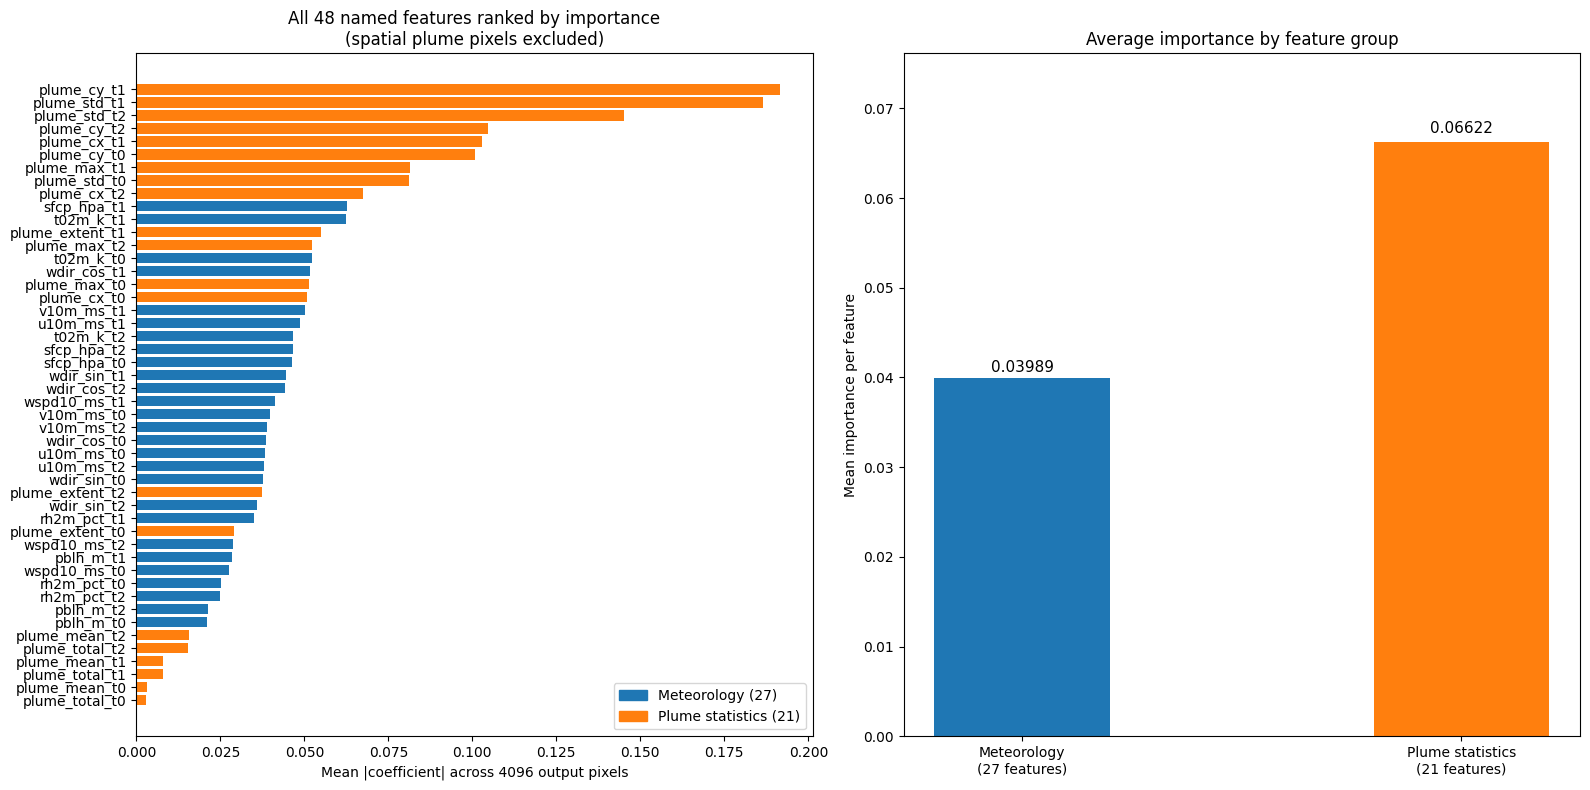

In [8]:
# ── Feature importance charts ──────────────────────────────────────────────

from matplotlib.patches import Patch

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# ── Left: all 48 named features ranked ────────────────────────────────────
ax = axes[0]
bar_colors = [
    "tab:blue" if i < N_MET else "tab:orange"
    for i in order[::-1]
]
ax.barh(
    [NAMED_FEATURES[i] for i in order[::-1]],
    named_imp[order[::-1]],
    color=bar_colors,
)
ax.set_xlabel("Mean |coefficient| across 4096 output pixels")
ax.set_title("All 48 named features ranked by importance\n(spatial plume pixels excluded)")
ax.legend(handles=[
    Patch(color="tab:blue",   label=f"Meteorology ({N_MET})"),
    Patch(color="tab:orange", label=f"Plume statistics ({N_STATS})"),
], loc="lower right")

# ── Right: group-level summary ─────────────────────────────────────────────
ax2 = axes[1]
group_labels = [
    f"Meteorology\n({N_MET} features)",
    f"Plume statistics\n({N_STATS} features)",
]
group_means  = [met_imp.mean(), stats_imp.mean()]
group_colors = ["tab:blue", "tab:orange"]
bars = ax2.bar(group_labels, group_means, color=group_colors, width=0.4)
for bar, val in zip(bars, group_means):
    ax2.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() * 1.01,
        f"{val:.5f}",
        ha="center", va="bottom", fontsize=11,
    )
ax2.set_ylabel("Mean importance per feature")
ax2.set_title("Average importance by feature group")
ax2.set_ylim(0, max(group_means) * 1.15)

plt.tight_layout()
plt.show()

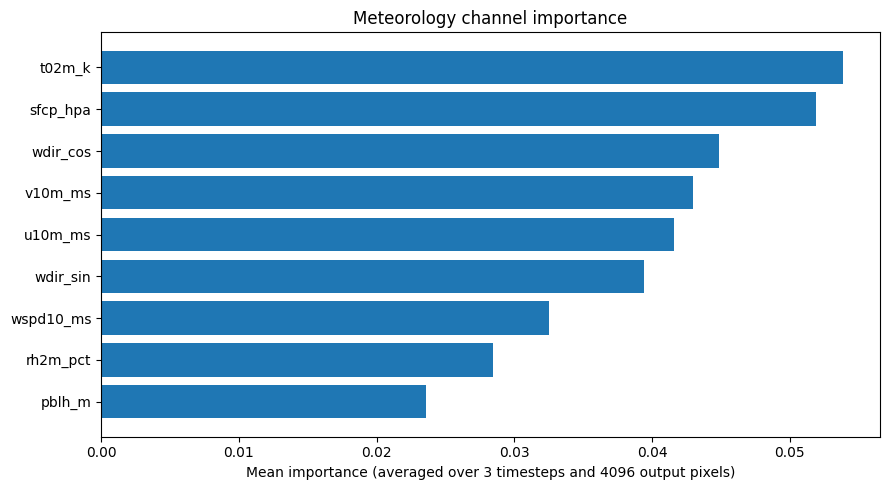

In [9]:
# ── Per-channel meteorology importance ─────────────────────────────────────

ch_means = np.array([
    named_imp[[j + t * len(MET_CHANNELS) for t in range(3)]].mean()
    for j in range(len(MET_CHANNELS))
])
ch_order = np.argsort(ch_means)  # ascending for horizontal bar (most important at top)

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(
    [MET_CHANNELS[i] for i in ch_order],
    ch_means[ch_order],
    color="tab:blue",
)
ax.set_xlabel("Mean importance (averaged over 3 timesteps and 4096 output pixels)")
ax.set_title("Meteorology channel importance")
plt.tight_layout()
plt.show()

Showing 9 samples from dataset of 40215:
  Indices: [0, 10053, 10849, 20107, 20555, 25615, 30161, 34207, 40214]

  #      File                           RMSE       R²
  ------------------------------------------------------
  0      000003_000.npz              0.26610      nan
  10053  002516_000.npz              0.29332      nan
  10849  002709_001.npz              0.30414      nan
  20107  005034_004.npz              0.27972      nan
  20555  005130_005.npz              0.70787      nan
  25615  006377_007.npz              0.99066      nan
  30161  007501_002.npz              0.37607      nan
  34207  008486_001.npz              0.47927      nan
  40214  009999_008.npz              0.27173      nan


c:\Users\joaoh\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_regression.py:1283: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
c:\Users\joaoh\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_regression.py:1283: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
c:\Users\joaoh\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_regression.py:1283: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
c:\Users\joaoh\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_regression.py:1283: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
c:\Users\joaoh\AppData\Local\Programs\Python\Python3

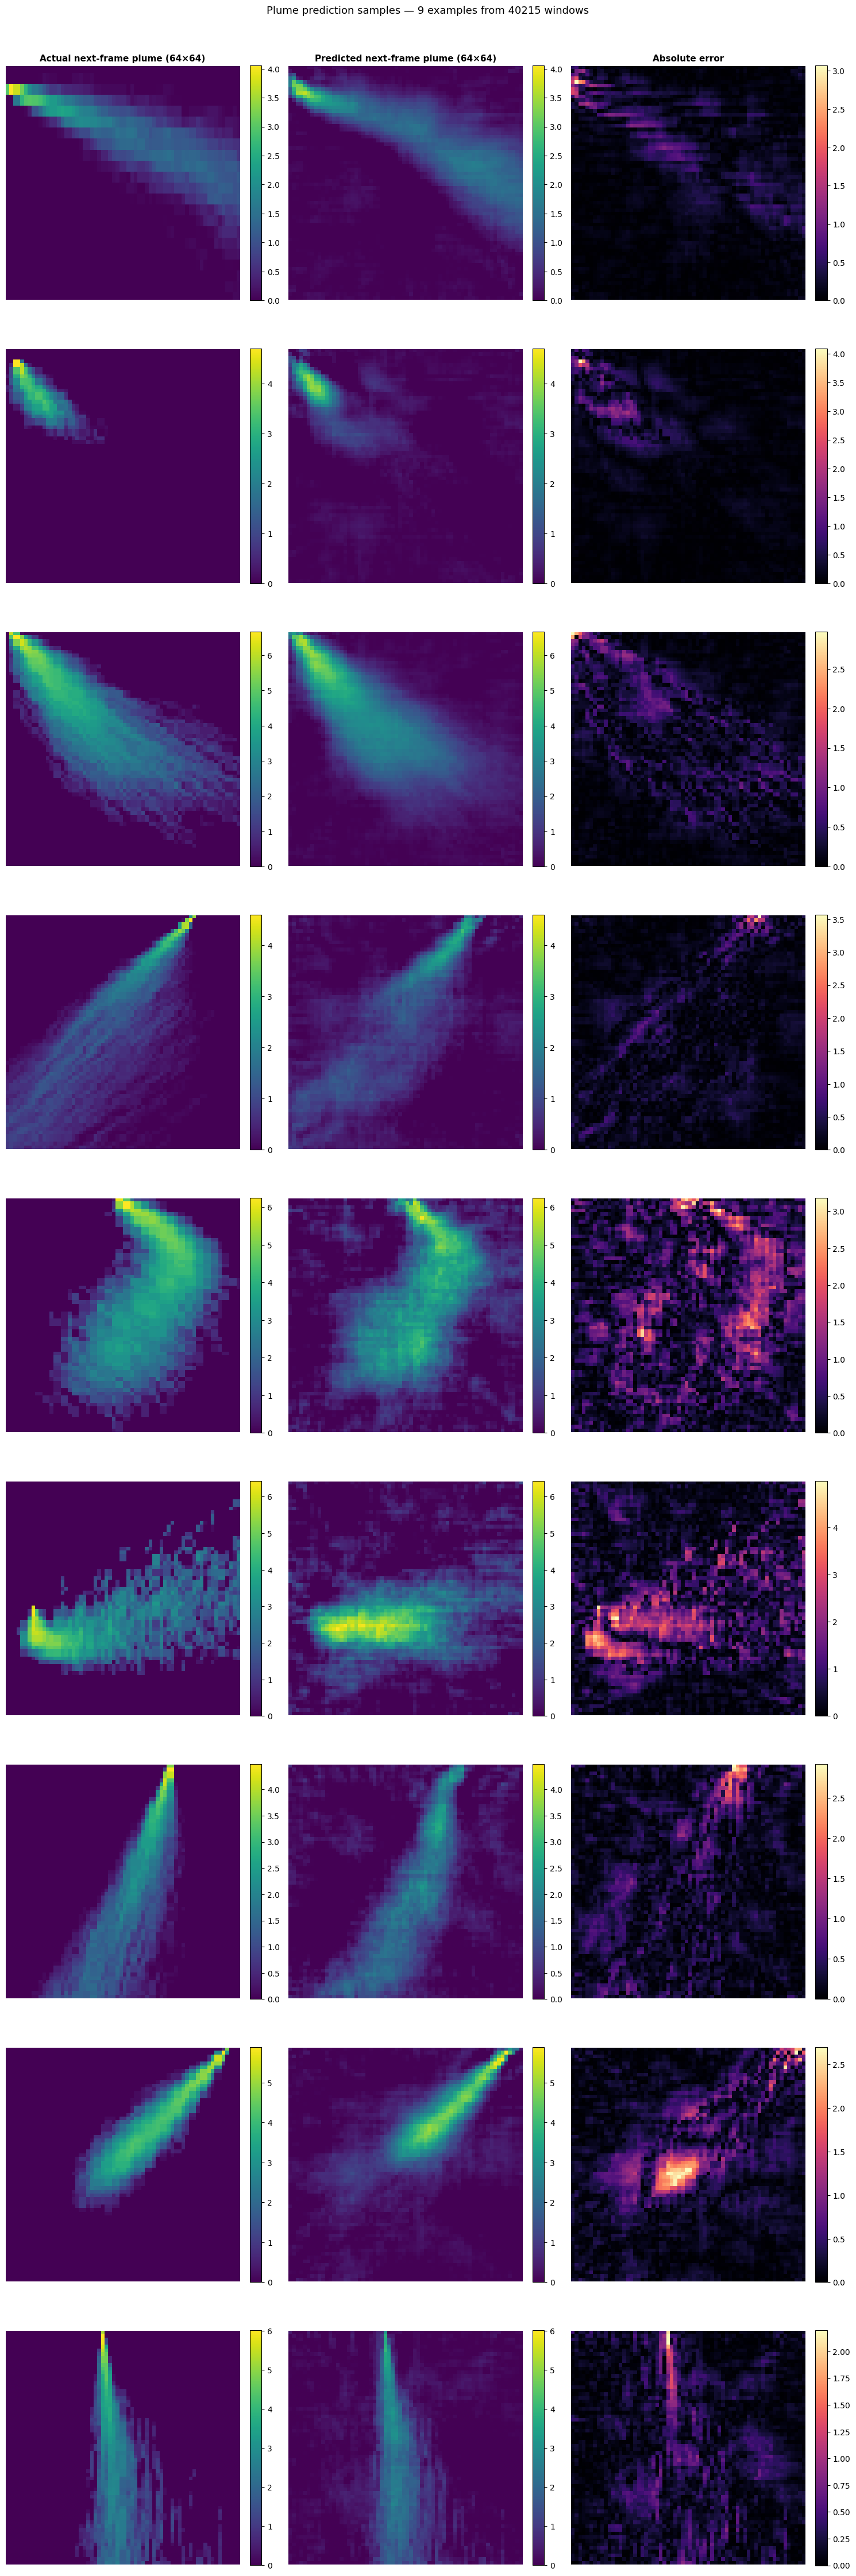

In [11]:
# ── Demo: predict and compare samples at full 64×64 resolution ─────────────
# Picks samples from the start, middle, and end of the dataset,
# plus a few random picks, to show a range of scenarios.

def predict_sample(index: int):
    path = window_paths[index]
    with np.load(path, allow_pickle=True) as d:
        feat      = extract_features(d["input"]).reshape(1, -1)
        true_flat = extract_target(d["target"])
    pred_flat   = model.predict(feat)[0]
    sample_rmse = np.sqrt(mean_squared_error(true_flat, pred_flat))
    sample_r2   = r2_score(
        true_flat.reshape(1, -1), pred_flat.reshape(1, -1),
        multioutput="uniform_average",
    )
    return path, true_flat, pred_flat, sample_rmse, sample_r2


n_total = len(window_paths)
rng     = np.random.default_rng(0)
sample_indices = sorted(set(
    [0, n_total // 4, n_total // 2, 3 * n_total // 4, n_total - 1]
    + rng.integers(0, n_total, size=4).tolist()
))[:9]  # show up to 9 samples

print(f"Showing {len(sample_indices)} samples from dataset of {n_total}:")
print(f"  Indices: {sample_indices}\n")

results = [predict_sample(i) for i in sample_indices]

# Print metrics table
print(f"  {'#':<6} {'File':<25} {'RMSE':>9} {'R²':>8}")
print("  " + "-" * 54)
for idx, (path, _, _, rmse, r2) in zip(sample_indices, results):
    print(f"  {idx:<6} {path.name:<25} {rmse:>9.5f} {r2:>8.4f}")

# ── Grid of figures: each row = one sample, cols = actual / predicted / error
n   = len(results)
fig, axes = plt.subplots(n, 3, figsize=(15, 5 * n))
if n == 1:
    axes = axes[np.newaxis, :]

col_titles = [
    "Actual next-frame plume (64×64)",
    "Predicted next-frame plume (64×64)",
    "Absolute error",
]
for col, title in enumerate(col_titles):
    axes[0, col].set_title(title, fontsize=11, fontweight="bold")

for row, (idx, (path, true_flat, pred_flat, rmse, r2)) in enumerate(
    zip(sample_indices, results)
):
    actual_grid = true_flat.reshape(64, 64)
    pred_grid   = pred_flat.reshape(64, 64)
    error_grid  = np.abs(actual_grid - pred_grid)
    vmax        = max(actual_grid.max(), pred_grid.max())

    for col, (grid, cmap, vmin, vmax_) in enumerate([
        (actual_grid, "viridis", 0.0, vmax),
        (pred_grid,   "viridis", 0.0, vmax),
        (error_grid,  "magma",   0.0, None),
    ]):
        ax = axes[row, col]
        im = ax.imshow(grid, cmap=cmap, vmin=vmin, vmax=vmax_)
        ax.axis("off")
        fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    axes[row, 0].set_ylabel(
        f"#{idx}  {path.name}\nRMSE={rmse:.4f}  R²={r2:.3f}",
        fontsize=8, rotation=0, labelpad=130, va="center",
    )

plt.suptitle(
    f"Plume prediction samples — {n} examples from {n_total} windows",
    fontsize=13, y=1.002,
)
plt.tight_layout()
plt.show()


## Interpretation

### Feature importance
Importance is measured as the **mean absolute Ridge coefficient** averaged over all 4 096 output pixels (64×64 target grid). A higher value means the feature shifts predicted concentration more, on average, across the spatial domain.

The 768 block-averaged spatial plume pixels are used by the model for location context but are **excluded from the importance chart** because their individual pixel contributions are not meaningfully interpretable on their own — what matters is the overall spatial structure, captured here by the plume statistics features.

### Absolute error map
The rightmost column in each demo sample shows where the model struggles spatially. Brighter cells are the least accurate. Because the model predicts at full 64×64 resolution using only aggregate features, fine-scale spatial detail comes from the block-averaged plume context; very localised plume structures may still be smoothed.

For sharper spatial reconstruction a ConvLSTM or U-Net would be more appropriate.